# How to Use the Time Series API

The `timeseries` API endpoints provide statistics for all points or intervals
along a time series. The `timeseries` family of endpoints works by converting
the provided time series parameters (`temporal`, `step`, and `temporal_mode`) into a set of
`temporal` query parameters for the corresponding lower-level endpoint, running asynchronous
requests to the lower-level endpoint, then collecting the results and formatting them in a coherent
format for the user.

The response is determined by the `temporal`, `step`, and `temporal_mode` parameters.

## Time Series API parameters

The `timeseries` API makes it possible to return results for many points along a time series with a single request.
The available parameters are:
- **`temporal`** (str): Either a date-time, an interval, or a comma-separated list of date-times or intervals. Date and time expressions adhere to rfc3339 ('2020-06-01T09:00:00Z') format.
- **`step`** (str): width of individual time steps expressed as a [IS8601 duration](https://en.wikipedia.org/wiki/ISO_8601#Durations)
- **`temporal_mode`** (str): if `"point"`, queries will be made for the individual timestamps along the time series. If `"interval"`, queries will be made for the periods *between* each timestamp along the time series. 

In general, it is best to use `temporal_mode=point` for datasets where granules overlap completely
in space (e.g. daily sea surface temperature predictions) because the `timeseries` endpoints will
create a mosaic of all assets returned by the query and the first asset to cover a pixel will
be used. For datasets where it requires granules from multiple timestamps to fully cover an AOI,
`temporal_mode=interval` is appropriate. For example, you can get weekly composites of satellite
imagery for visualization purposes with `step=P1W & temporal_mode=interval`.

There are many ways to combine the parameters to produce a time series.

1. Exact points in time from a start to and end datetime:
  - provide `temporal={start_datetime}/{end_datetime}`, `step={step_width}`, and `temporal_mode=point` where `step_width` is something like `P1D` for daily or `P2W` for bi-weekly.
  - provide `temporal={start_datetime}/{end_datetime}`, and `temporal_mode=point` without `step` to get a point for every unique timestamp in the granules between `start_datetime` and `end_datetime`.
2. Fixed-width intervals between a start and end datetime:
  - provide `temporal={start_datetime}/{end_datetime}`, `step`, and `temporal_mode=interval`
3. Specific datetimes
  - provide `temporal=2024-10-01T00:00:01Z,2024-10-02T00:00:01Z`
4. Specific datetime intervals
  - provide `temporal=2024-10-01T00:00:01Z/2024-10-01T23:59:59Z,2024-10-05T00:00:01Z/2024-10-05T23:59:59Z`

The `timeseries` API documentation is embedded as an iframe below.

In [ ]:
import os

from IPython.display import IFrame

titiler_endpoint = os.getenv(
    "TITILER_CMR_ENDPOINT", "https://openveda.cloud/api/titiler-cmr"
)

IFrame(f"{titiler_endpoint}/api.html#Timeseries", 900, 500)

## Example API Use

Every `/timeseries` request in `titiler.cmr` will require both a `collection_concept_id` and a set of time series parameters. The [GHRSST Level 4 GAMSSA_28km Global Foundation Sea Surface Temperature Analysis v1.0 dataset (GDS2)](https://cmr.earthdata.nasa.gov/search/concepts/C2036881735-POCLOUD.html) is a useful dataset for demo purposes because the granule assets are small (~1MB each).

See [Time series API limits](../time_series_api_limits/) for details on limits to the spatial and temporal extent for requests to TiTiler-CMR.

## Setup

In [ ]:
import json
from datetime import datetime

import httpx
import matplotlib.pyplot as plt
import numpy as np
from folium import LayerControl, Map, TileLayer
from geojson_pydantic import Feature, Polygon
from IPython.display import Image, display

collection_concept_id = "C2036881735-POCLOUD"

## GET Requests

Making a `GET` request to the `/timeseries` endpoint is useful for demonstrating how the timeseries family of endpoints constructs sub-requests. It returns the list of `titiler.cmr` query parameters (`temporal` and `collection_concept_id`) that will be used to generate the timeseries results.

### Timeseries for all granules between a start/end datetime

For some datasets that have granules that are regularly spaced in time (e.g. daily), it is useful to be able to quickly specify a summary of all points in time between a start and end datetime. You can do that by simply providing the `start_datetime` and `end_datetime` parameters. The application will query CMR and produce a list of unique `temporal` values from the results of the granule search. If a granule represents a datetime range, it will return the midpoint between the start and end for a single granule.

In [ ]:
response = httpx.get(
    f"{titiler_endpoint}/timeseries",
    params={
        "collection_concept_id": collection_concept_id,
        "temporal": "2024-10-01T00:00:01Z/2024-10-05T00:00:01Z",
    },
    timeout=None,
).json()

print(json.dumps(response, indent=2))

### Weekly timeseries

Sometimes you might be interested in a report with lower temporal resolution than the maximum availble for a dataset. By setting `step="P1W"` and `temporal_mode="point"`, you can get a weekly series.

In [ ]:
response = httpx.get(
    f"{titiler_endpoint}/timeseries",
    params={
        "collection_concept_id": collection_concept_id,
        "temporal": "2024-10-01T00:00:01Z/2024-10-30T00:00:01Z",
        "step": "P1W",
        "temporal_mode": "point",
    },
    timeout=None,
).json()

print(json.dumps(response, indent=2))

### Periodic timeseries

Some datasets (like satellite imagery) may consist of granules that do not fully cover an arbitrary area of interest. In this case it is useful to construct a time series from a set of datetime ranges so that granules can be mosaiced to ensure each step has full coverage.

To create a set of non-overlapping week-long datetime ranges, you can modify the query to use `temporal_mode="interval"` which will create ranges that start on the weekly values returned in the previous query and extend up to the second before the next value in the series.

In [ ]:
response = httpx.get(
    f"{titiler_endpoint}/timeseries",
    params={
        "collection_concept_id": collection_concept_id,
        "temporal": "2024-10-01T00:00:01Z/2024-10-30T00:00:01Z",
        "step": "P1W",
        "temporal_mode": "interval",
    },
    timeout=None,
).json()

print(json.dumps(response, indent=2))

### Custom time series
If you want to specify the exact datetime values for a timeseries and you either cannot do not want to use the time series parameters, you can supply a set of comma-separated datetimes and/or datetime ranges to the `temporal` parameter.

In [ ]:
response = httpx.get(
    f"{titiler_endpoint}/timeseries",
    params={
        "collection_concept_id": collection_concept_id,
        "temporal": ",".join(
            ["2024-10-01T00:00:01Z", "2024-10-07T00:00:01Z/2024-10-09T23:59:59Z"]
        ),
    },
    timeout=None,
).json()

print(json.dumps(response, indent=2))

## BBOX GIF Endpoint

The `/timeseries/bbox` endpoint can be used to produce a GIF that shows a visualization of granules over time.  

### For the GAMSAA dataset using `xarray`

The example below shows biweekly sea surface temperature estimates from the GAMSSA dataset for the period from November 2023 through October 2024.

In [ ]:
minx, miny, maxx, maxy = -180, -90, 180, 90
request = httpx.get(
    f"{titiler_endpoint}/xarray/timeseries/bbox/{minx},{miny},{maxx},{maxy}.gif",
    params={
        "collection_concept_id": collection_concept_id,
        "temporal": "2023-11-01T00:00:01Z/2024-10-30T23:59:59Z",
        "step": "P2W",
        "temporal_mode": "point",
        "variables": "analysed_sst",
        "colormap_name": "nipy_spectral",
        "rescale": [[275, 305]],
    },
    timeout=None,
)
display(Image(request.content))

### For the HLS dataset using `rasterio`

The example below shows a weekly mosaic of imagery from the Harmonized Landsat Sentinel L30 (HLSL30) collection for the period from July through October 2021 in the area of the [Greenwood Fire](https://en.wikipedia.org/wiki/Greenwood_Fire).

In [ ]:
minx, miny, maxx, maxy = -91.816, 47.491, -91.359, 47.716
request = httpx.get(
    f"{titiler_endpoint}/rasterio/timeseries/bbox/{minx},{miny},{maxx},{maxy}/512x512.gif",
    params={
        "collection_concept_id": "C2021957657-LPCLOUD",
        "temporal": "2021-07-01T00:00:00Z/2021-10-30T00:00:00Z",
        "step": "P5D",
        "temporal_mode": "interval",
        "assets_regex": "B[0-9][0-9]",
        "assets": ["B04", "B03", "B02"],
        "color_formula": "Gamma RGB 3.5 Saturation 1.7 Sigmoidal RGB 15 0.35",
        "fps": 2,
    },
    timeout=None,
)

display(Image(request.content))

## Statistics Endpoint

The `/timeseries/statistics` endpoint will produce summary statistics for an AOI for all points along a timeseries.

### Example with GAMSAA

The example below shows daily sea surface temperature summary statistics for the Gulf of Mexico from the GAMSSA dataset for the period from March 2023 through October 2024.

In [ ]:
%%time
minx, miny, maxx, maxy = -98.676, 18.857, -81.623, 31.097
geojson = Feature(
    type="Feature",
    geometry=Polygon.from_bounds(minx, miny, maxx, maxy),
    properties={},
)
request = httpx.post(
    f"{titiler_endpoint}/xarray/timeseries/statistics",
    params={
        "collection_concept_id": collection_concept_id,
        "temporal": "2023-03-01T00:00:01Z/2024-10-30T23:59:59Z",
        "step": "P1D",
        "temporal_mode": "point",
        "variables": "analysed_sst",
    },
    json=geojson.model_dump(exclude_none=True),
    timeout=None,
)

request.raise_for_status()
response = request.json()

The `/timeseries/statistics` endpoint returns the GeoJSON with statistics for each step in the time series embedded in the properties.

In [ ]:
stats = response["properties"]["statistics"]
print(len(stats))

stats_preview = {
    timestamp: sst_stats
    for i, (timestamp, sst_stats) in enumerate(stats.items())
    if i < 2
}
print(json.dumps(stats_preview, indent=2))

The statistics output can be used to generate plots like this:

In [ ]:
data = response["properties"]["statistics"]

dates = []
means = []
stds = []

for date_str, values in data.items():
    date_str = date_str.split("/")[0]
    stats = list(values.values())[0]
    dates.append(datetime.fromisoformat(date_str))
    means.append(stats["mean"])
    stds.append(stats["std"])

plt.figure(figsize=(10, 6))

plt.plot(dates, means, "b-", label="Mean")

plt.fill_between(
    dates,
    np.array(means) - np.array(stds),
    np.array(means) + np.array(stds),
    alpha=0.2,
    color="b",
    label="Standard Deviation",
)

plt.xlabel("Date")
plt.ylabel("Temperature (K)")
plt.title("Mean sea surface temperature in the Gulf of Mexico")
plt.legend()

plt.xticks(rotation=45)

plt.tight_layout()

plt.show()

### Example with HLS NDVI

The example below shows NDVI summary statistics for a field in central Minnesota for 5 day periods in 2025. It uses the `expression` parameter to set cloud and cloud-shadow pixels to -9999 then calculates NDVI for the remaining pixels (unless NDVI works out to an infinite value). This approach uses `numpy.where` to evaluate the logical expression in Python in the TiTiler-CMR application. Since we are just interested in valid, non-cloud values we need to use the `histogram` to calculate summary statistics that are not affected by the -9999 fill value that we sub in for pixels that are covered with clouds or cloud shadows. We can limit the histogram to report only counts in pixels that are in the approximate valid range for NDVI (-2, 2) `histogram_range` and `histogram_bins`.

In [ ]:
geojson = {
    "type": "Feature",
    "properties": {},
    "geometry": {
        "type": "Polygon",
        "coordinates": [
            [
                [-95.032331363541601, 45.96131018544132],
                [-95.032298519174063, 45.958981317010398],
                [-95.030721989532694, 45.958958484482402],
                [-95.030065102182135, 45.958410500988201],
                [-95.027536085882431, 45.9583648354524],
                [-95.027437552779816, 45.963935753041284],
                [-95.029868035976946, 45.963798769982255],
                [-95.030196479652218, 45.962931202742709],
                [-95.032331363541601, 45.96131018544132],
            ]
        ],
    },
}


# identify pixels where the Fmask value does not indicate cloud or cloud shadow
not_cloud = "(Fmask & 14) == 0"

# NDVI formula
ndvi = "(B05-B04)/(B05+B04)"

request = httpx.post(
    f"{titiler_endpoint}/rasterio/timeseries/statistics",
    params={
        "collection_concept_id": "C2021957657-LPCLOUD",
        "temporal": "2025-01-01T00:00:00Z/2025-12-31T23:59:59Z",
        # "sort_key": "cloud_cover",  # can use this after merging https://github.com/developmentseed/titiler-cmr/pull/175
        "temporal_mode": "interval",
        "step": "P5D",
        "assets_regex": "B[0-9][0-9]|Fmask",
        # expression to calculate non-cloud ndvi values
        "expression": f"where(1 * ({not_cloud}) * isfinite({ndvi}) == 1, {ndvi}, -9999)",
        # limit histogram to 20 evenly-sized bins between -2 and 2
        "histogram_range": "-2,2",
        "histogram_bins": 20,
    },
    json=geojson,
    timeout=None,
)

request.raise_for_status()
response = request.json()

In [ ]:
stats = response["properties"]["statistics"]

stats_preview = {
    timestamp: sst_stats
    for i, (timestamp, sst_stats) in enumerate(stats.items())
    if i < 2
}
print(json.dumps(stats_preview, indent=2))

/tmp/ipykernel_114218/2318555928.py:16: RuntimeWarning: invalid value encountered in scalar divide
  median = l_bound + ((median_target - f_prev) / f_median_bin) * w


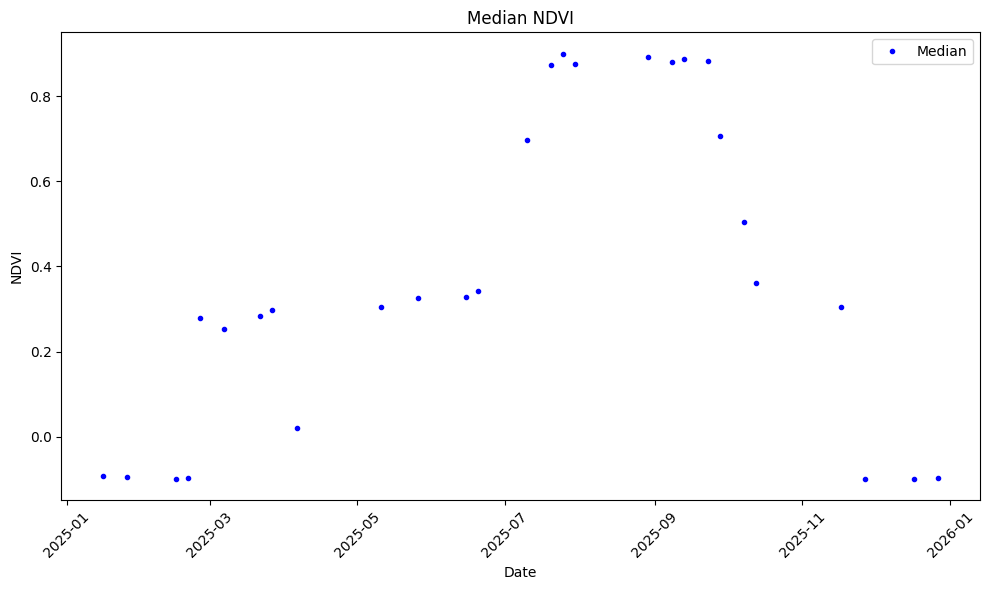

In [57]:
def estimate_median(counts, bin_edges):
    """Estimate median value from histogram counts/edges"""
    total_n = np.sum(counts)
    cumulative_counts = np.cumsum(counts)
    median_target = total_n / 2

    # Find the bin containing the median
    idx = np.where(cumulative_counts >= median_target)[0][0]

    l_bound = bin_edges[idx]
    f_prev = cumulative_counts[idx - 1] if idx > 0 else 0
    f_median_bin = counts[idx]
    w = bin_edges[idx + 1] - bin_edges[idx]

    # Linear Interpolation
    median = l_bound + ((median_target - f_prev) / f_median_bin) * w
    return median


data = response["properties"]["statistics"]

dates = []
medians = []

for date_str, values in data.items():
    date_str = date_str.split("/")[0]
    stats = list(values.values())[0]
    dates.append(datetime.fromisoformat(date_str))
    medians.append(estimate_median(*stats["histogram"]))

plt.figure(figsize=(10, 6))

plt.plot(dates, medians, "b.", label="Median")

plt.xlabel("Date")
plt.ylabel("NDVI")
plt.title("Median NDVI")
plt.legend()

plt.xticks(rotation=45)

plt.tight_layout()

plt.show()

## Tilejson Endpoint

It could be useful to allow users to select a timestep in an interactive map. You can use the `/timeseries/tilejson` endpoint for that purpose. The following example shows how you could use it to provide time series capability to an interactive map of sea ice cover.

In [ ]:
minx, miny, maxx, maxy = -180, -90, 180, 90
request = httpx.get(
    f"{titiler_endpoint}/xarray/timeseries/WebMercatorQuad/tilejson.json",
    params={
        "collection_concept_id": collection_concept_id,
        "temporal": "2023-11-01T00:00:01Z/2024-10-30T23:59:59Z",
        "step": "P1M",
        "temporal_mode": "point",
        "variables": "sea_ice_fraction",
        "colormap_name": "blues_r",
        "rescale": [[0, 1]],
    },
    timeout=None,
)
tilejsons = request.json()
tilejson_preview = {
    timestamp: tilejson
    for i, (timestamp, tilejson) in enumerate(tilejsons.items())
    if i < 2
}
print(json.dumps(tilejson_preview, indent=2))

In [ ]:
m = Map(location=[0, 0], zoom_start=1, min_zoom=1)
for datetime_, tilejson in tilejsons.items():
    label = datetime.fromisoformat(datetime_.split("/")[0]).strftime("%Y-%m")
    TileLayer(
        tiles=tilejson["tiles"][0],
        attr="GAMSSA SST",
        overlay=True,
        name=label,
        show=False,
    ).add_to(m)
LayerControl(collapsed=False).add_to(m)
m